## KNN Decision Boundaries

A **decision boundary** is the region where KNN switches from predicting one class to another.

| Factor | Effect |
|---|---|
| **Small k** | Complex, jagged boundary — follows noise (**overfitting**) |
| **Large k** | Smooth, simple boundary — may miss patterns (**underfitting**) |
| **Euclidean** distance | Circular / elliptical boundaries |
| **Manhattan** distance | Axis-aligned (rectangular) boundaries |

**Plotting steps:** create a dense grid over the feature space → classify every grid point with KNN → color by predicted class. The boundary appears where colors change.

#### Code Breakdown

> **`make_classification()`** — generates a synthetic labeled dataset for testing classifiers.

| Parameter | Meaning |
|---|---|
| `n_samples=200` | 200 data points |
| `n_features=2` | 2 features (plottable in 2D) |
| `n_informative=2` | Both features carry signal |
| `n_redundant=0` | No redundant features |
| `n_clusters_per_class=1` | Each class = one cluster |

..

> **Grid & helper functions**

| Function | What it does | Example |
|---|---|---|
| `np.arange(0, 1, 0.3)` | Evenly spaced values | `[0.0, 0.3, 0.6, 0.9]` |
| `np.meshgrid(x, y)` | All (x, y) combinations as 2D arrays | `[1,2]` x `[3,4]` → grid of 4 points |
| `.ravel()` | Flatten 2D → 1D | `[[1,2],[3,4]]` → `[1,2,3,4]` |
| `zip(axes, k_values)` | Pair items from two lists | `[(ax1,1), (ax2,3), ...]` |

[[[1, 2], [3, 4]], [[1, 2], [3, 4]]]
[1 2 3 4 1 2 3 4]


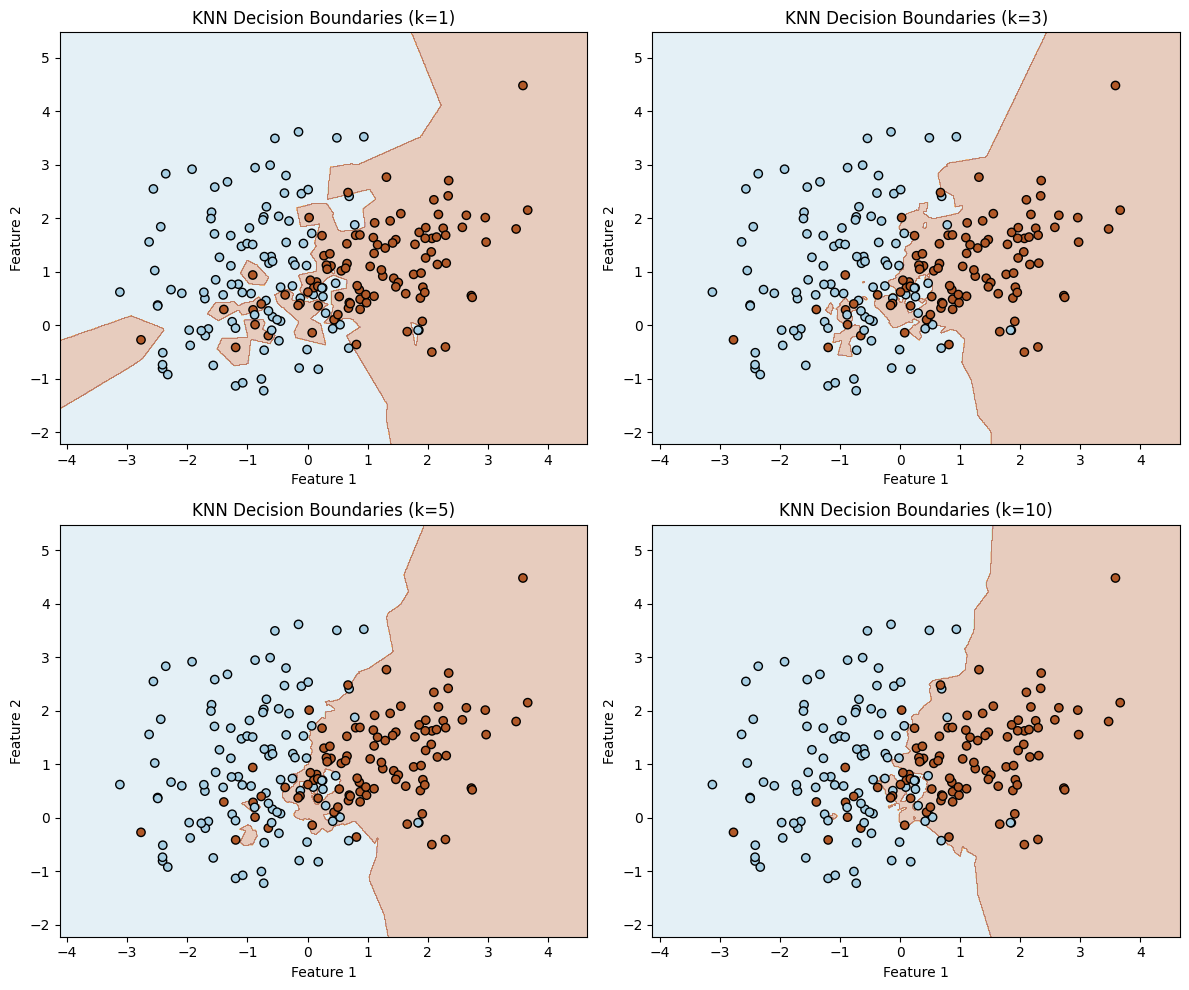

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier


X, y = make_classification(
    n_samples=200, 
    n_features=2, 
    n_informative=2, 
    n_redundant=0, 
    n_clusters_per_class=1, 
    random_state=42
)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
k_values = [1, 3, 5, 10]

for ax, k in zip(axs.flat, k_values):

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X, y)
    
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k',
               cmap=plt.cm.Paired, marker='o')
    ax.set_title(f'KNN Decision Boundaries (k={k})')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()